In [2]:
import vitaldb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Find cases containing arterial pressure
abp_cases = vitaldb.find_cases(['ART'])

print("Cases with ART:", len(abp_cases))
print(abp_cases[:20])

/tmp/ipykernel_3388200/3920463723.py:2: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  abp_cases = vitaldb.find_cases(['ART'])


Cases with ART: 3645
[1, 3, 4, 7, 10, 12, 13, 14, 16, 17, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31]


In [4]:
ppg_cases = vitaldb.find_cases(['PLETH'])

print("Cases with PLETH:", len(ppg_cases))
print(ppg_cases[:20])

Cases with PLETH: 6157
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21]


/tmp/ipykernel_3388200/195122844.py:1: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  ppg_cases = vitaldb.find_cases(['PLETH'])


In [5]:
common_cases = sorted(
    set(abp_cases).intersection(ppg_cases)
)

print("Cases with both PPG and ABP:", len(common_cases))
print(common_cases[:20])

Cases with both PPG and ABP: 3459
[1, 3, 4, 7, 10, 13, 14, 16, 17, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31, 32]


In [21]:
case_id = common_cases[10]
data = vitaldb.load_case(
    case_id,
    ['PLETH', 'ART'],
    1/125
)

print(data.shape)

(3309447, 2)


In [ ]:
vf = vitaldb.VitalFile(case_id)

tracks = vf.get_track_names()

for track in tracks:
    if 'PLETH' in track.upper() or 'ART' in track.upper():
        print(track)

Solar8000/ART_MBP
Solar8000/ART_SBP
Solar8000/ART_DBP
Solar8000/PLETH_SPO2
Solar8000/PLETH_HR
SNUADC/ART
SNUADC/PLETH


: 

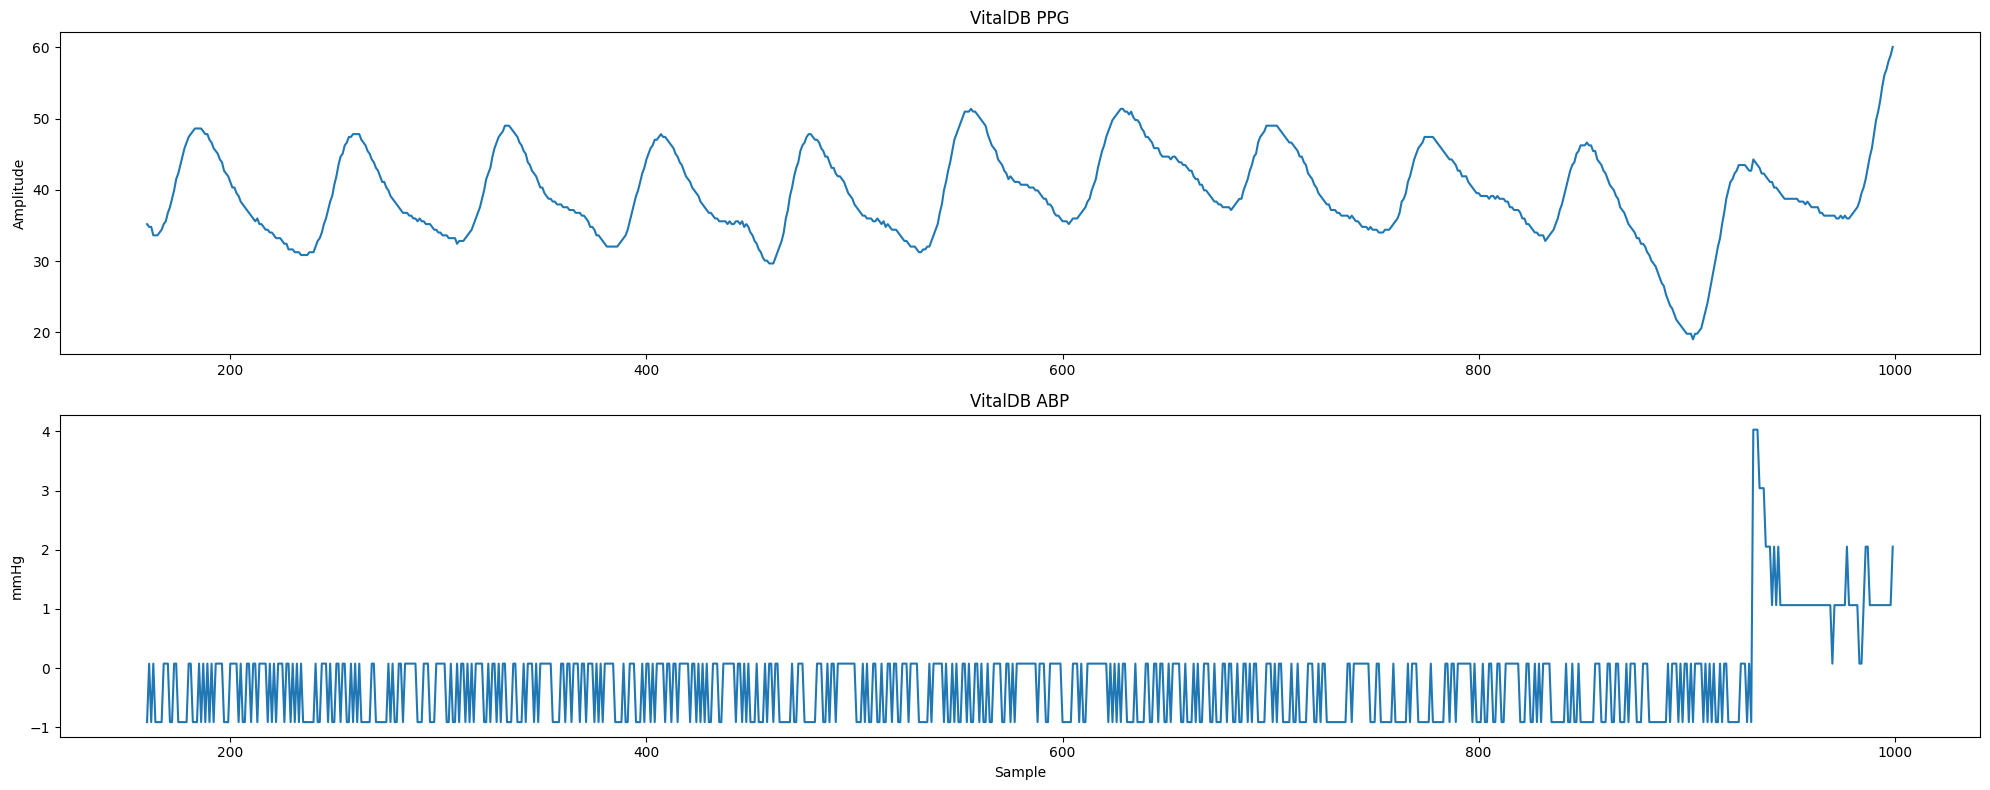

In [18]:
ppg = data[:, 0][:1000]
abp = data[:, 1][:1000]

plt.figure(figsize=(20, 8))

plt.subplot(2, 1, 1)
plt.plot(ppg)
plt.title("VitalDB PPG")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(abp)
plt.title("VitalDB ABP")
plt.ylabel("mmHg")
plt.xlabel("Sample")

plt.tight_layout()
plt.show()

In [19]:
print("PPG:")
print("min =", np.nanmin(ppg))
print("max =", np.nanmax(ppg))
print("mean =", np.nanmean(ppg))
print("std =", np.nanstd(ppg))

print("\nABP:")
print("min =", np.nanmin(abp))
print("max =", np.nanmax(abp))
print("mean =", np.nanmean(abp))
print("std =", np.nanstd(abp))

PPG:
min = 18.990158
max = 60.06836
mean = 39.38302
std = 6.2448378

ABP:
min = -0.9100342
max = 4.027252
mean = -0.26348478
std = 0.7145724
